<div style="text-align: center">
    <h2><font size=6>MODELO - Inception V3</font></h2>
</d>
</div>

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import SGD

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
#Definimos ruta de dataset
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "dataset_final/train"
val_dir = "dataset_final/validation"
test_dir = "dataset_final/test"

CLASSES = ['AgeDegeneration', 'cataract', 'diabetic_retinopathy', 'glaucoma', 'healthy', 'Myopia']
NUM_CLASSES = len(CLASSES)

In [3]:
#Definimos generadores de datos
# Entrenamiento con aumento de datos
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Validación y test sin augmentación
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4455 images belonging to 6 classes.
Found 952 images belonging to 6 classes.
Found 959 images belonging to 6 classes.


In [4]:
#Construcción del modelo (InceptionV3
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Congelar la base
for layer in base_model.layers:
    layer.trainable = False

# Head personalizada
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [6]:
optimizer = SGD(
    learning_rate=0.001,
    momentum=0.9
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 111, 111, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 111, 111, 32)      │              96 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 111, 111, 32)      │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 109, 109, 32)      │           9,216 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 109, 109, 32)      │              96 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 109, 109, 32)      │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 109, 109, 64)      │          18,432 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 109, 109, 64)      │             192 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 109, 109, 64)      │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 54, 54, 64)        │               0 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 54, 54, 80)        │           5,120 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 54, 54, 80)        │             240 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_3 (Activation)     │ (None, 54, 54, 80)        │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 52, 52, 192)       │         138,240 │ activation_3[0][0]         │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 22,328,870 (85.18 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [9]:
#Entrenamiento del modelo
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40
)

Epoch 1/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 132s 940ms/step - accuracy: 0.5924 - loss: 1.0907 - val_accuracy: 0.6586 - val_loss: 0.9883
Epoch 2/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 131s 936ms/step - accuracy: 0.6251 - loss: 1.0199 - val_accuracy: 0.6628 - val_loss: 0.9517
Epoch 3/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 131s 933ms/step - accuracy: 0.6368 - loss: 0.9718 - val_accuracy: 0.6450 - val_loss: 0.9465
Epoch 4/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 130s 930ms/step - accuracy: 0.6595 - loss: 0.9397 - val_accuracy: 0.6838 - val_loss: 0.8925
Epoch 5/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 129s 922ms/step - accuracy: 0.6696 - loss: 0.9118 - val_accuracy: 0.6775 - val_loss: 0.8709
Epoch 6/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 129s 919ms/step - accuracy: 0.6786 - loss: 0.8838 - val_accuracy: 0.6943 - val_loss: 0.8601
Epoch 7/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 129s 920ms/step - accuracy: 0.6795 - loss: 0.8819 - val_accuracy: 0.6912 - val_loss: 0.8436
Epoch 8/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 130s 930ms/step - accuracy: 0.6882 -

In [11]:
model.save("modelo_inception.keras")

In [13]:
val_loss, val_accuracy = model.evaluate(val_generator, verbose=1)
print(f"Loss en validación: {val_loss}")
print(f"Precisión en validación: {val_accuracy}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 633ms/step - accuracy: 0.7395 - loss: 0.7170
Loss en validación: 0.7169809937477112
Precisión en validación: 0.7394958138465881


In [14]:
test_loss, test_acc = model.evaluate(test_generator)
print("Perdida en test: ", test_loss)
print("Precision en test: ", test_acc)

30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 655ms/step - accuracy: 0.7508 - loss: 0.6711
Perdida en test:  0.6711136102676392
Precision en test:  0.7507820725440979


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [16]:
predictions = model.predict(test_generator, verbose=1)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 710ms/step


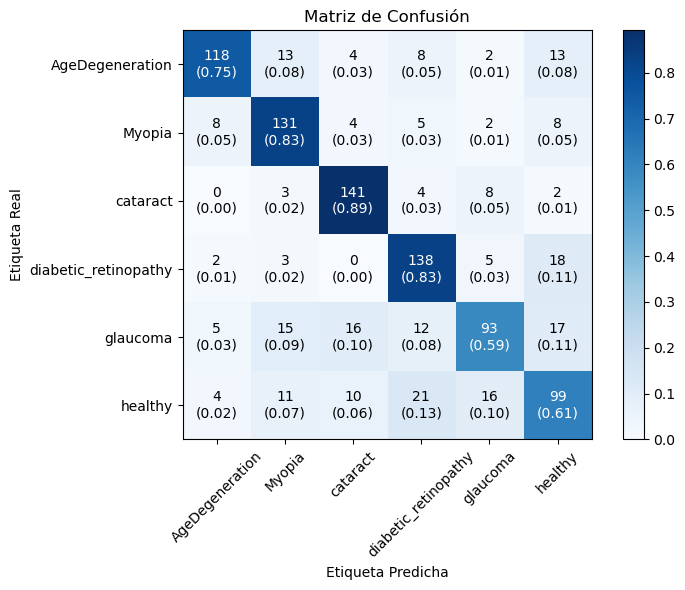

In [17]:
conf_matrix = confusion_matrix(true_classes, predicted_classes)

conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
plt.imshow(conf_matrix_normalized, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.colorbar()

classes = class_labels
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = conf_matrix_normalized.max() / 2.

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):

        absolute_value = conf_matrix[i, j]
        percentage_value = conf_matrix_normalized[i, j]

        plt.text(j, i,
                 f'{absolute_value}\n({percentage_value:.2f})',
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if percentage_value > thresh else "black")

plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

In [18]:
print("Reporte de Clasificación:")

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

Reporte de Clasificación:
                      precision    recall  f1-score   support

     AgeDegeneration       0.86      0.75      0.80       158
              Myopia       0.74      0.83      0.78       158
            cataract       0.81      0.89      0.85       158
diabetic_retinopathy       0.73      0.83      0.78       166
            glaucoma       0.74      0.59      0.65       158
             healthy       0.63      0.61      0.62       161

            accuracy                           0.75       959
           macro avg       0.75      0.75      0.75       959
        weighted avg       0.75      0.75      0.75       959



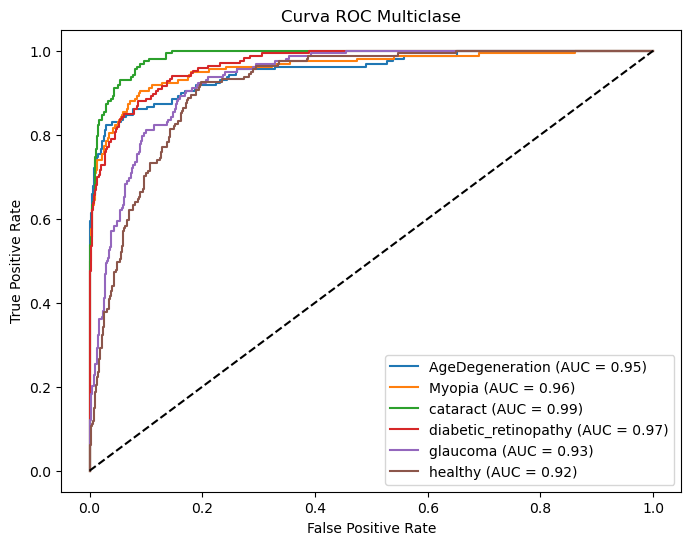

In [19]:
y_true_bin = label_binarize(true_classes, classes=range(len(class_labels)))

plt.figure(figsize=(8,6))

for i in range(len(class_labels)):

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], predictions[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{class_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC Multiclase')
plt.legend()

plt.show()